# Detección Adaptativa de Carriles en Condiciones de Iluminación Variable
## Seguimiento 2: Primera versión de la implementación

**Grupo 9:** Hugo Toro Meca, Miguel García Losada, Daniel Salamanca Garrido

---

### Resumen del Notebook
Este cuaderno presenta la implementación práctica del sistema de visión por computador detallado en el artículo *"Robust Lane Detection under Varying Lighting Conditions Using Adaptive Vision-Based Techniques"* .

El objetivo de este documento es construir y explicar de forma didáctica un *pipeline* algorítmico capaz de detectar las líneas de la carretera, ajustando dinámicamente sus técnicas de procesamiento según el nivel de luz del entorno desarrollando paso a paso el uso de filtros morfológicos, enmascaramiento espacial y transformadas geométricas .

A lo largo del cuaderno definiremos las funciones matemáticas requeridas, justificaremos los parámetros elegidos y visualizaremos los resultados intermedios de los algoritmos (Canny, Hough y HSV) para evaluar su robustez.

### 1. Importación de Librerías y Preparación del Entorno

Para implementar el sistema propuesto en el artículo y poder procesar las imágenes de nuestra base de datos, nos apoyaremos en las siguientes librerías estándar de Python:

* **OpenCV (`cv2`)**: Es el motor principal de visión por computador de nuestro trabajo. Nos proporciona las implementaciones optimizadas de los algoritmos clásicos que necesitamos, como las conversiones de espacio de color (Grises, HSV), los filtros espaciales (Desenfoque Gaussiano, Canny) y las transformadas geométricas (Transformada de Hough).
* **NumPy (`np`)**: Es fundamental para el cálculo numérico. En Python, las imágenes se procesan como matrices multidimensionales. NumPy nos permite aplicar operaciones matemáticas rápidas sobre estas matrices, como el cálculo de la media para el detector de brillo o el promediado geométrico de las pendientes de los carriles.
* **Matplotlib (`plt`)**: Será nuestra herramienta de visualización didáctica. La usaremos para incrustar las imágenes resultantes y renderizar los pasos intermedios de las máscaras directamente en este cuaderno.
* **OS**: Una librería del sistema necesaria para interactuar con las rutas de los archivos, lo que nos permitirá automatizar la lectura de los miles de fotogramas secuenciales de nuestra base de datos.
* **Math**: Proporciona operaciones matemáticas estándar. La utilizaremos para calcular el logaritmo en base 10 exigido matemáticamente por la fórmula de la Corrección Gamma adaptativa.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

## 2. Definición de Variables Globales y Carga de Datos

Para evaluar empíricamente la robustez de nuestro algoritmo frente a distintas condiciones de iluminación, utilizaremos dos bases de datos (datasets) estándar en la industria de la conducción autónoma. Dado que cada base de datos tiene una estructura de archivos diferente, hemos diseñado funciones de carga independientes:

* **Dataset TuSimple (Secuencias Cortas):** Su estructura se basa en múltiples subcarpetas, donde cada una representa un clip de vídeo corto (aprox. 20 fotogramas cronológicos). Es ideal para evaluar la *consistencia temporal* de nuestro algoritmo y comprobar si las líneas "parpadean" entre un fotograma y el siguiente.
* **Dataset Udacity (Test de Estrés):** Consiste en un único directorio masivo con decenas de miles de fotogramas (aprox. 28.000 imágenes). Lo utilizaremos como banco de pruebas principal para someter al sistema a un test de estrés prolongado frente a cambios drásticos de iluminación (sombras densas, destellos, transición día/noche). 

Para evitar problemas de desbordamiento de memoria (RAM) al procesar la base de datos de Udacity en este entorno interactivo, la función de carga incorpora un parámetro limitador (`max_frames`) que nos permitirá extraer y procesar solo los segmentos que necesitemos para cada prueba.

In [ ]:
# Cambiar por la ruta donde tengamos nustra BD
RUTA_TUSIMPLE = r"C:\Users\Dani\Desktop\Trabajo PID\BD\BD1\TUSimple\test_set\clips\0530"
RUTA_NOCTURNA = r"C:\Users\Dani\Desktop\Trabajo PID\BD\BD2\BD_Noche2" #Tres subcarpetas: 0530, 0531, 0601
RUTA_UDACITY = r"C:\Users\Dani\Desktop\Trabajo PID\BD\BD3\data\export"

In [ ]:
def cargar_secuencia_tusimple(ruta_base):
    """
    Lee la estructura de subcarpetas anidadas de TuSimple.
    Elige un clip de vídeo al azar y devuelve sus fotogramas ordenados cronológicamente.
    """
    carpetas_videos = [os.path.join(ruta_base, d) for d in os.listdir(ruta_base) 
                       if os.path.isdir(os.path.join(ruta_base, d))]
    
    if not carpetas_videos:
        print("Error: No se encontraron subcarpetas de vídeo en la ruta de TuSimple.")
        return []
        
    carpeta_elegida = random.choice(carpetas_videos)
    nombre_video = os.path.basename(carpeta_elegida)
    
    fotogramas = sorted([os.path.join(carpeta_elegida, f) for f in os.listdir(carpeta_elegida) 
                         if f.endswith('.jpg') or f.endswith('.png')])
                         
    print(f"TuSimple cargado: Seleccionado clip '{nombre_video}' con {len(fotogramas)} fotogramas.")
    return fotogramas


def cargar_secuencia_udacity(ruta_base, max_frames=300):
    """
    Lee la estructura plana de Udacity (un directorio masivo).
    Devuelve los fotogramas ordenados, limitados a 'max_frames' para evitar colapsos de RAM.
    """
    fotogramas = sorted([os.path.join(ruta_base, f) for f in os.listdir(ruta_base) 
                         if f.endswith('.jpg') or f.endswith('.png')])
                         
    total_disponibles = len(fotogramas)
    
    if total_disponibles == 0:
        print("Error: No se encontraron imágenes en la ruta de Udacity.")
        return []
        
    fotogramas_recortados = fotogramas[:max_frames]
    print(f"Udacity cargado: Extraídos {len(fotogramas_recortados)} fotogramas (de {total_disponibles} disponibles).")
    return fotogramas_recortados


def cargar_secuencia_bd2_nocturna(ruta_base):
    """
    Lee la estructura de subcarpetas de la BD2 (Nocturna).
    Elige un clip de vídeo al azar y devuelve sus fotogramas ordenados cronológicamente.
    """
    carpetas_videos = [os.path.join(ruta_base, d) for d in os.listdir(ruta_base) 
                       if os.path.isdir(os.path.join(ruta_base, d))]
    
    if not carpetas_videos:
        print("Error: No se encontraron subcarpetas de vídeo en la ruta de BD2.")
        return []
        
    carpeta_elegida = random.choice(carpetas_videos)
    nombre_video = os.path.basename(carpeta_elegida)
    
    fotogramas = sorted([os.path.join(carpeta_elegida, f) for f in os.listdir(carpeta_elegida) 
                         if f.endswith('.jpg') or f.endswith('.png')])
                         
    print(f"BD2 Nocturna cargada: Seleccionado clip '{nombre_video}' con {len(fotogramas)} fotogramas.")
    return fotogramas


# ==========================================
# EJEMPLO DE USO (Descomenta el que quieras usar)
# ==========================================
# Seleccionamos con qué dataset queremos que trabaje el cuaderno a partir de este punto:

# fotogramas_a_procesar = cargar_secuencia_tusimple(RUTA_TUSIMPLE)
# fotogramas_a_procesar = cargar_secuencia_udacity(RUTA_UDACITY, max_frames=500)
fotogramas_a_procesar = cargar_secuencia_bd2_nocturna(RUTA_BD2_NOCTURNA)

TuSimple cargado: Seleccionado clip '1492635605257947499_0' con 20 fotogramas.


**Comprobación visual del Dataset:** Para asegurarnos de que las rutas son correctas y las imágenes se han indexado adecuadamente, extraemos y visualizamos 4 fotogramas aleatorios del dataset que acabamos de cargar en memoria.

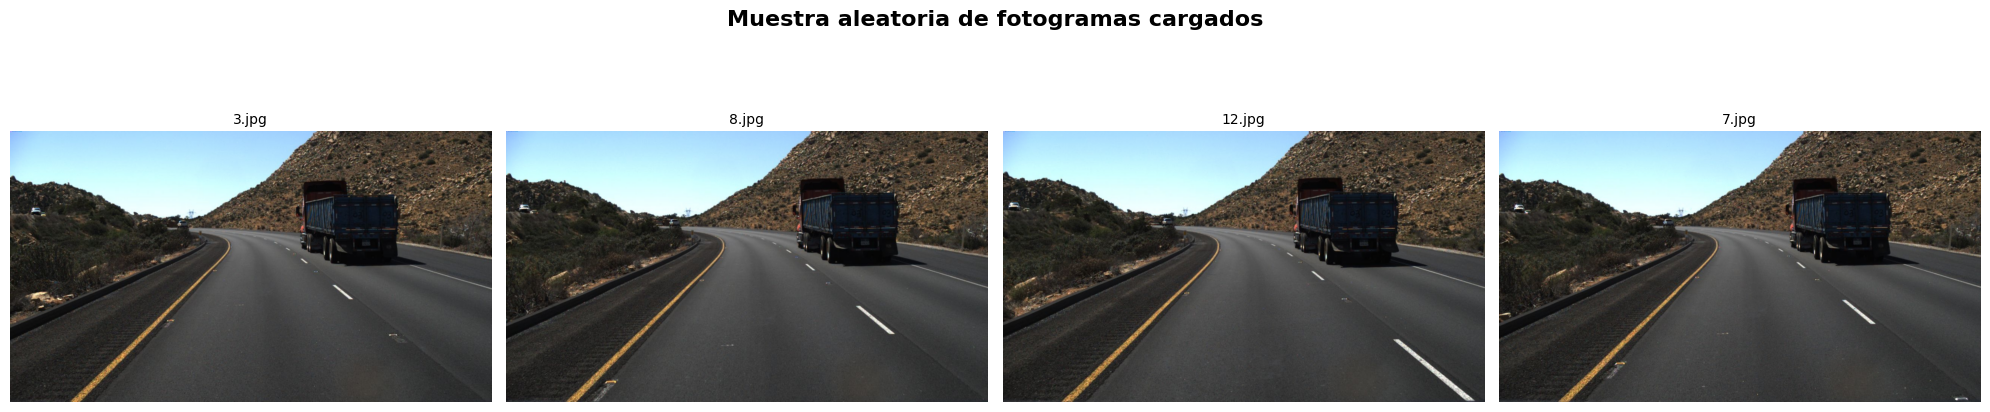

In [4]:
import random

# Verificamos que la variable del dataset existe y tiene datos
if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    
    # Elegimos 4 imágenes al azar (o menos, si el dataset fuera más pequeño)
    num_muestras = min(4, len(fotogramas_a_procesar))
    muestras = random.sample(fotogramas_a_procesar, num_muestras)
    
    # Preparamos una figura con 4 columnas
    fig, axs = plt.subplots(1, num_muestras, figsize=(20, 5))
    fig.suptitle("Muestra aleatoria de fotogramas cargados", fontsize=16, fontweight='bold')
    
    # Si solo hay 1 imagen, axs no es un array, lo convertimos para evitar errores
    if num_muestras == 1: axs = [axs]
        
    for i, ruta in enumerate(muestras):
        img = cv2.imread(ruta)
        if img is not None:
            # Pasamos a RGB para que Matplotlib no cambie los colores
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
            axs[i].imshow(img_rgb)
            
            # Mostramos el nombre del archivo como título de la foto
            nombre_archivo = os.path.basename(ruta)
            axs[i].set_title(nombre_archivo, fontsize=10)
            
        axs[i].axis('off') # Quitamos los ejes numéricos para que quede más limpio
        
    plt.tight_layout()
    plt.show()
    
else:
    print("¡Aviso! No se han detectado fotogramas. Asegúrate de ejecutar la celda anterior y descomentar uno de los datasets.")

## 3. Clasificador Dinámico de Iluminación (Día/Noche)

La principal contribución del artículo de referencia es la adaptabilidad del algoritmo frente a los cambios ambientales. Para lograrlo, el sistema debe ser capaz de evaluar la cantidad de luz de un fotograma en tiempo real y decidir qué ruta de procesamiento (*pipeline*) tomar.

Según se detalla en la sección 3.4 del artículo, este proceso se realiza analizando la intensidad lumínica global de la imagen. El algoritmo sigue estos pasos matemáticos exactos:

**1. Conversión al espacio de color Grises:**
La imagen original se transforma a escala de grises para aislar la información de intensidad lumínica (descartando la saturación y el tono).

**2. Cálculo del Brillo Medio (Ecuación 37):**
Se calcula la media aritmética de las intensidades de todos los píxeles de la imagen. Matemáticamente, el brillo promedio $B$ se define como:

$$B = \frac{1}{M \times N} \sum_{i=1}^{M} \sum_{j=1}^{N} I_{gray}(i,j)$$

Donde:
* $M$ y $N$ representan el alto y el ancho de la imagen (dimensiones de la matriz).
* $I_{gray}(i,j)$ es el valor de intensidad (de 0 a 255) del píxel en la coordenada $(i,j)$.

**3. Decisión mediante Umbralización (Ecuación 38):**
Una vez obtenido el brillo medio $B$, se evalúa contra un umbral predefinido $T$. Los autores del artículo establecen empíricamente que **$T = 50$**. La función de clasificación $F(B)$ se define como:

$$ 
F(B) = 
\begin{cases} 
1 & \text{si } B > 50 \implies \text{MODO DÍA} \\
0 & \text{si } B \leq 50 \implies \text{MODO NOCHE} 
\end{cases}
$$

A continuación, implementamos este modelo matemático aprovechando la función `np.mean()` de NumPy, la cual realiza la sumatoria y división de la matriz de forma altamente optimizada.

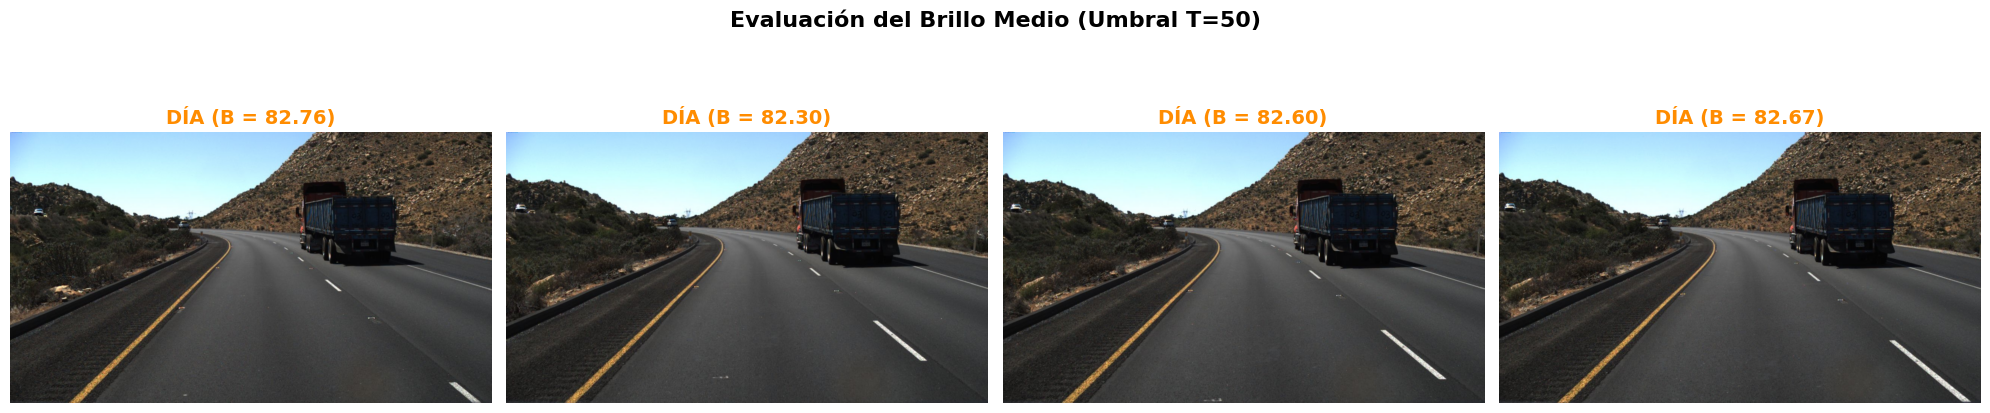

In [5]:
# ==========================================
# 3. IMPLEMENTACIÓN DEL CLASIFICADOR DE LUZ
# ==========================================

def evaluar_iluminacion(imagen, umbral=50):
    """
    Implementa la Ec. 37 y 38 del artículo para clasificar el fotograma.
    
    Parámetros:
        imagen: Matriz numpy (fotograma BGR cargado con OpenCV).
        umbral: Valor de decisión (T=50 según el artículo).
        
    Retorna:
        imagen_gris: La imagen convertida a escala de grises.
        brillo_medio: El valor flotante exacto de B.
        modo: String ("DÍA" o "NOCHE").
    """
    
    # 1. Transformación a Grises (I_gray)
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # 2. Cálculo del brillo promedio B (sumatoria / (M x N))
    # np.mean es matemáticamente equivalente a la Ecuación 37
    brillo_medio = np.mean(imagen_gris)
    
    # 3. Regla de decisión lógica (Ecuación 38)
    if brillo_medio > umbral:
        modo = "DÍA"
    else:
        modo = "NOCHE"
        
    return imagen_gris, brillo_medio, modo


# --- COMPROBACIÓN DEL CLASIFICADOR ---
# Vamos a evaluar las primeras 4 imágenes cargadas en la variable global
if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    
    # Cogemos 4 imágenes en orden para ver cómo cambia la secuencia
    imagenes_test = fotogramas_a_procesar[:4]
    
    fig, axs = plt.subplots(1, len(imagenes_test), figsize=(20, 5))
    fig.suptitle("Evaluación del Brillo Medio (Umbral T=50)", fontsize=16, fontweight='bold')
    
    if len(imagenes_test) == 1: axs = [axs]
        
    for i, ruta in enumerate(imagenes_test):
        img_bgr = cv2.imread(ruta)
        
        # Ejecutamos nuestra función matemática
        img_gris, B, modo = evaluar_iluminacion(img_bgr)
        
        # Mostramos la imagen en RGB para apreciar mejor la luz real
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img_rgb)
        
        # Color del título según el modo
        color = 'darkorange' if modo == "DÍA" else 'darkblue'
        axs[i].set_title(f"{modo} (B = {B:.2f})", fontsize=14, color=color, fontweight='bold')
        axs[i].axis('off')
        
    plt.tight_layout()
    plt.show()

## 4. Pipeline del Modo Día: Detección Clásica de Bordes

Cuando el fotograma supera el umbral de iluminación ($B > 50$), el sistema asume que las condiciones de visibilidad son óptimas. En este escenario, el artículo propone un enfoque secuencial basado en filtros morfológicos y geométricos clásicos para extraer los carriles.

Para demostrar visualmente este proceso, seleccionaremos un fotograma de prueba de nuestro dataset y aplicaremos las transformaciones paso a paso.

### 4.1. Preprocesamiento: Escala de Grises y Suavizado Gaussiano
El primer paso es reducir la complejidad computacional y el ruido de alta frecuencia.
1. **Escala de grises:** Descartamos los canales RGB. La geometría de los carriles se basa en el contraste de intensidades, no en el color (durante el día).
2. **Desenfoque Gaussiano:** Las carreteras tienen una textura rugosa que el sistema podría interpretar erróneamente como miles de micro-bordes. Aplicamos una convolución con un *kernel* Gaussiano (una matriz de 5x5) que actúa como un filtro de paso bajo, promediando los píxeles vecinos para "difuminar" el asfalto sin perder las líneas principales.

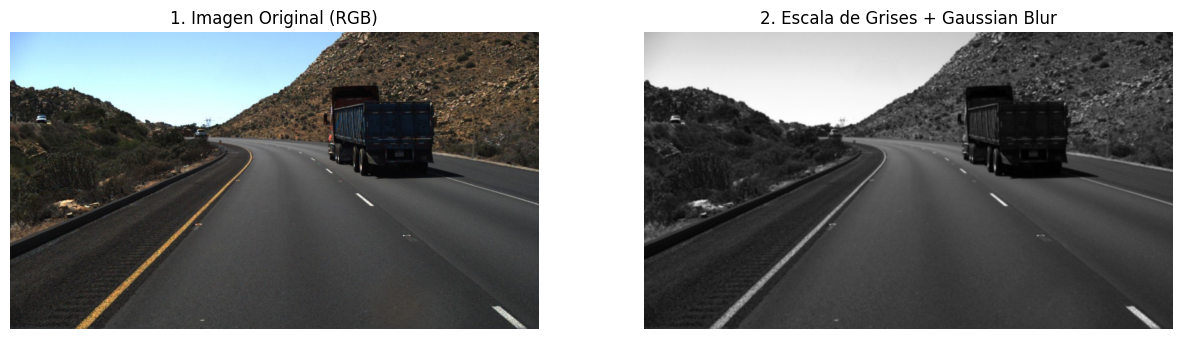

In [6]:
# ==========================================
# 4.1. PREPROCESAMIENTO
# ==========================================

# Seleccionamos la primera imagen disponible en nuestra variable de datos
if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    ruta_prueba_dia = fotogramas_a_procesar[0] # Cogemos el frame 0
    img_dia = cv2.imread(ruta_prueba_dia)
    img_dia_rgb = cv2.cvtColor(img_dia, cv2.COLOR_BGR2RGB)
    
    # 1. Escala de grises
    img_gris = cv2.cvtColor(img_dia, cv2.COLOR_BGR2GRAY)
    
    # 2. Desenfoque Gaussiano (Kernel 5x5)
    img_blur = cv2.GaussianBlur(img_gris, (5, 5), 0)
    
    # Visualización
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].imshow(img_dia_rgb)
    axs[0].set_title("1. Imagen Original (RGB)")
    axs[1].imshow(img_blur, cmap='gray')
    axs[1].set_title("2. Escala de Grises + Gaussian Blur")
    for ax in axs: ax.axis('off')
    plt.show()
else:
    print("Por favor, carga primero el dataset en la sección 2.")

### 4.2. Detección de transiciones: Filtro de Canny

Una vez suavizada la imagen, buscamos los puntos exactos donde el asfalto oscuro se encuentra con la pintura blanca brillante. Esto se modela matemáticamente buscando grandes gradientes de intensidad (las derivadas de la imagen).

El **Filtro de Canny** calcula este gradiente espacial y aplica un proceso de histéresis mediante dos umbrales (50 y 150). Los píxeles cuyo gradiente supere 150 se consideran "bordes fuertes". Los que estén entre 50 y 150 se aceptan solo si están conectados espacialmente a un borde fuerte, eliminando así el ruido residual.

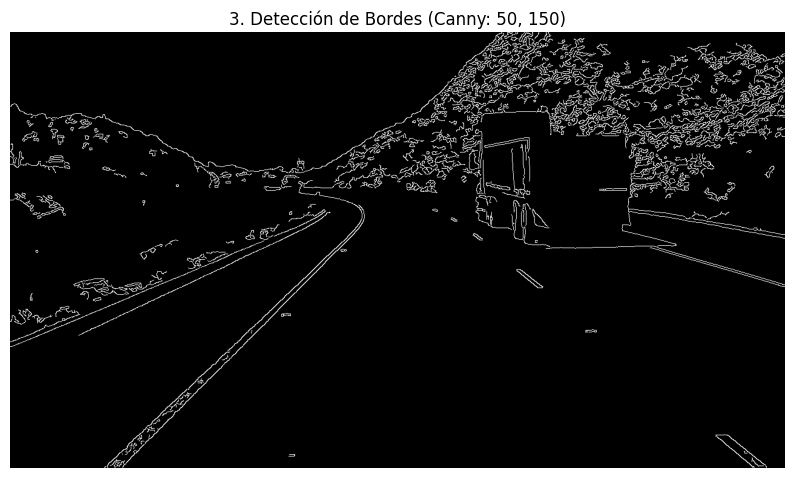

In [7]:
# ==========================================
# 4.2. DETECCIÓN DE BORDES (CANNY)
# ==========================================

# Aplicamos el filtro de Canny sobre la imagen suavizada
umbrales_canny = (50, 150)
img_canny = cv2.Canny(img_blur, umbrales_canny[0], umbrales_canny[1])

# Visualización
plt.figure(figsize=(10, 6))
plt.imshow(img_canny, cmap='gray')
plt.title(f"3. Detección de Bordes (Canny: {umbrales_canny[0]}, {umbrales_canny[1]})")
plt.axis('off')
plt.show()

### 4.3. Enmascaramiento Espacial: Región de Interés (ROI)

Como se puede observar en la salida del filtro de Canny, el algoritmo detecta *todos* los bordes visibles: nubes, árboles, coches aparcados, etc. Sin embargo, por las leyes de la perspectiva, sabemos que nuestro propio carril siempre estará en una porción muy específica frente a la cámara.

Para evitar procesar información inútil, generamos una **Máscara Poligonal (ROI - Region of Interest)**. Creamos una matriz negra, dibujamos un trapecio blanco sobre la zona de la carretera y aplicamos una operación lógica multiplicativa (`bitwise_and`). Todo lo que caiga fuera del trapecio se multiplicará por 0, desapareciendo.

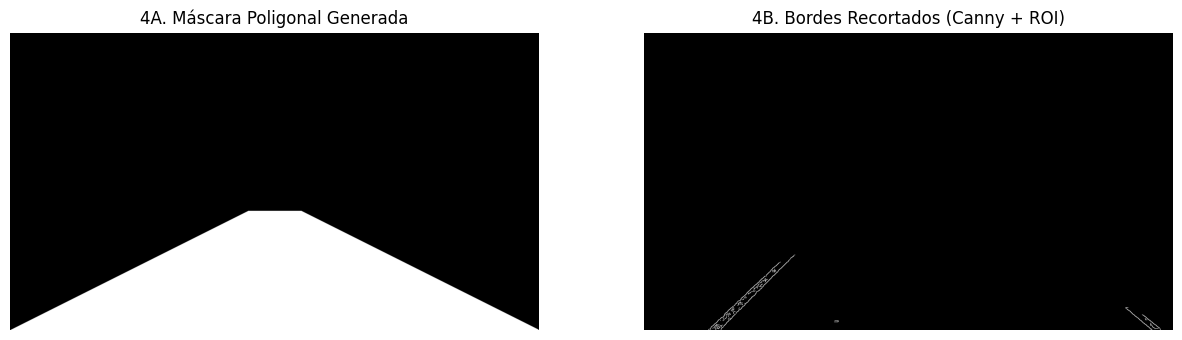

In [8]:
# ==========================================
# 4.3. ENMASCARAMIENTO (ROI)
# ==========================================

alto, ancho = img_canny.shape

# 1. Definir los vértices del trapecio dinámicamente según el tamaño de la imagen
poligono_roi = np.array([[
    (0, alto),                                     # Esquina inferior izquierda
    (ancho, alto),                                 # Esquina inferior derecha
    (int(ancho * 0.55), int(alto * 0.6)),          # Vértice superior derecho
    (int(ancho * 0.45), int(alto * 0.6))           # Vértice superior izquierdo
]])

# 2. Crear máscara negra y rellenar el polígono de blanco (255)
mascara = np.zeros_like(img_canny)
cv2.fillPoly(mascara, poligono_roi, 255)

# 3. Aplicar operación lógica AND
img_roi = cv2.bitwise_and(img_canny, mascara)

# Visualización
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(mascara, cmap='gray')
axs[0].set_title("4A. Máscara Poligonal Generada")
axs[1].imshow(img_roi, cmap='gray')
axs[1].set_title("4B. Bordes Recortados (Canny + ROI)")
for ax in axs: ax.axis('off')
plt.show()

### 4.4. Extracción de Líneas: Transformada de Hough (PHT)

Finalmente, necesitamos que el ordenador entienda que esos píxeles blancos dispersos forman líneas rectas. Para ello se emplea la **Transformada Probabilística de Hough**.

Este algoritmo convierte los puntos del espacio cartesiano de la imagen (x, y) a curvas en el "Espacio de Hough" (parámetros polares $\rho$ y $\theta$). Si muchas curvas colisionan en un mismo punto en ese espacio, significa que todos esos píxeles pertenecen a la misma recta. OpenCV nos devuelve directamente las coordenadas iniciales y finales $(x_1, y_1, x_2, y_2)$ de los segmentos detectados.

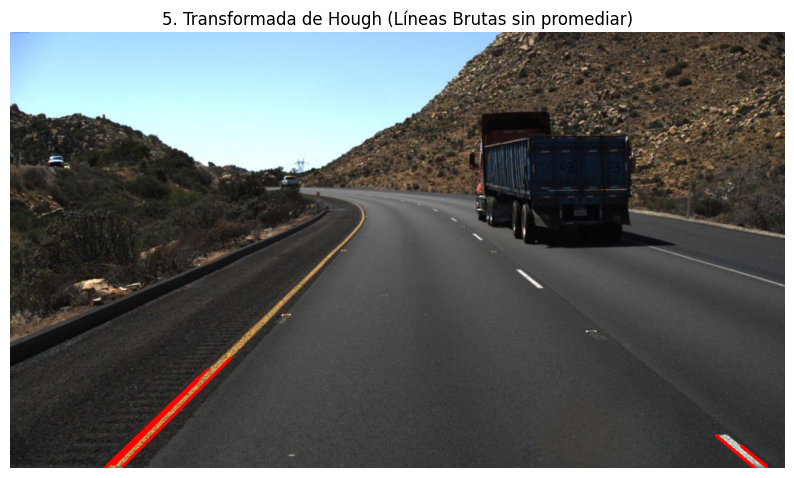

In [9]:
# ==========================================
# 4.4. TRANSFORMADA DE HOUGH (Líneas Brutas)
# ==========================================

# Parámetros exigidos por la teoría para detectar segmentos
rho = 1               # Resolución de distancia en píxeles
theta = np.pi / 180   # Resolución angular en radianes
threshold = 50        # Mínimo de colisiones en el Espacio de Hough
min_line_length = 40  # Longitud mínima de la línea en píxeles
max_line_gap = 150    # Distancia máxima entre píxeles para conectarlos

# Ejecutar PHT
lineas_brutas = cv2.HoughLinesP(img_roi, rho, theta, threshold, 
                                minLineLength=min_line_length, maxLineGap=max_line_gap)

# Dibujar las líneas detectadas (segmentos sueltos) sobre la imagen RGB
img_hough = np.copy(img_dia_rgb)
if lineas_brutas is not None:
    for linea in lineas_brutas:
        x1, y1, x2, y2 = linea[0]
        # Dibujamos las líneas en rojo
        cv2.line(img_hough, (x1, y1), (x2, y2), (255, 0, 0), 4)

# Visualización
plt.figure(figsize=(10, 6))
plt.imshow(img_hough)
plt.title("5. Transformada de Hough (Líneas Brutas sin promediar)")
plt.axis('off')
plt.show()